Метод Рунге-Кутты 2-го порядка
Оптимальное chi: 0.9999985538689347056291718744145611093376658810789
Начальное u(0): 0.0000025616928158470509703801894807693905091585578383863
Решение u(r): 3.1489004776253553550773930860644737388090135763933E-8
Решение F(r): 368.42135584729314151747039837392265755460098808542
k_linear(r): 1.6
k_quadratic(r): 1.6
dudr(r): -5.8947416935566902642795263739827625208736158093667E-8

k_linear(0.1575): 182.219690000
k_quadratic(0.1575): 181.02935073350000000
dudr(0.1575): -0.0000326030480989622957446005492647000000000
r =  0.3500 



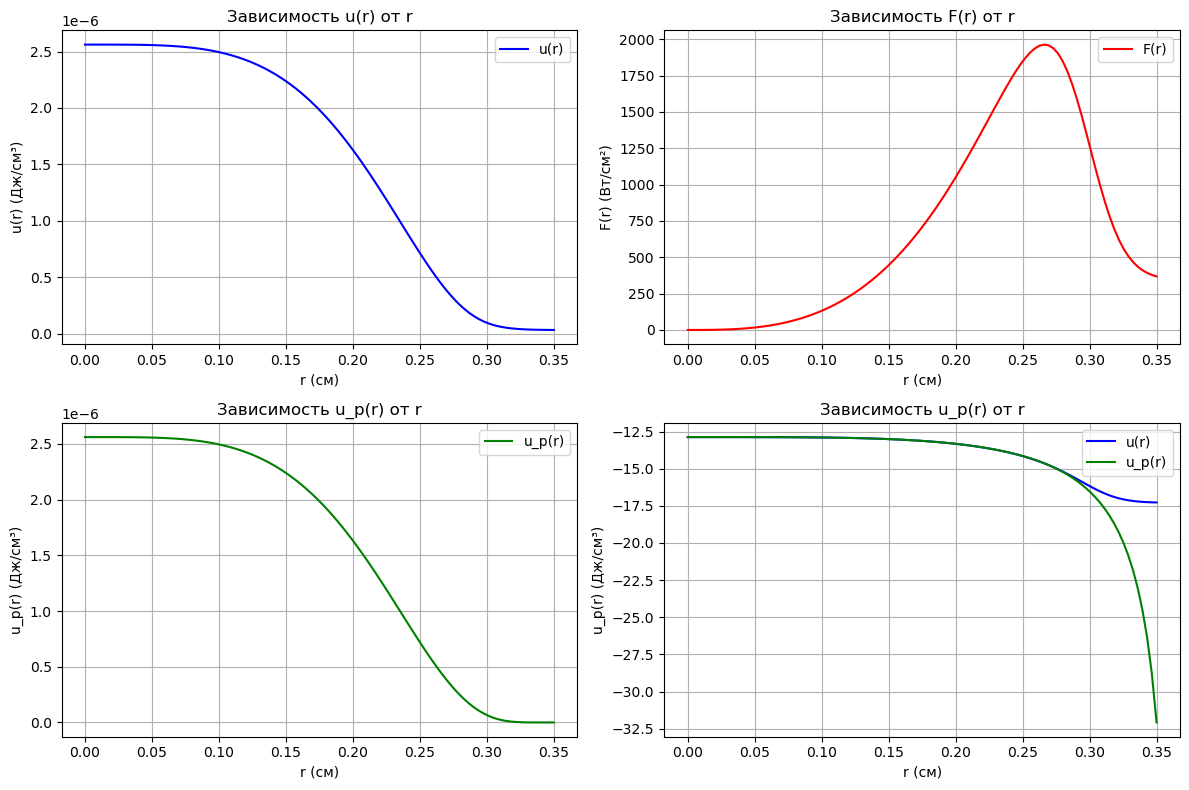

Метод Рунге-Кутты 4-го порядка
Оптимальное chi: 0.9999988469639559144281079192856921667366381408056
Начальное u(0): 0.0000025616935666675469463431514222593668894376282035988
Решение u(r): 3.1249368832462144002507982421810590940960124342944E-8
Решение F(r): 365.61761531521025273801895754843911071434242586129
k_linear(r): 1.6
k_quadratic(r): 1.6
dudr(r): -5.8498818450433640438083033207750257714294788137806E-8

k_linear(0.1575): 182.219690000
k_quadratic(0.1575): 181.02935073350000000
dudr(0.1575): -0.0000326030480989622957446005492647000000000
r =  0.3500
Fmax =  1965.4445909001439676339567505924398386190093654878


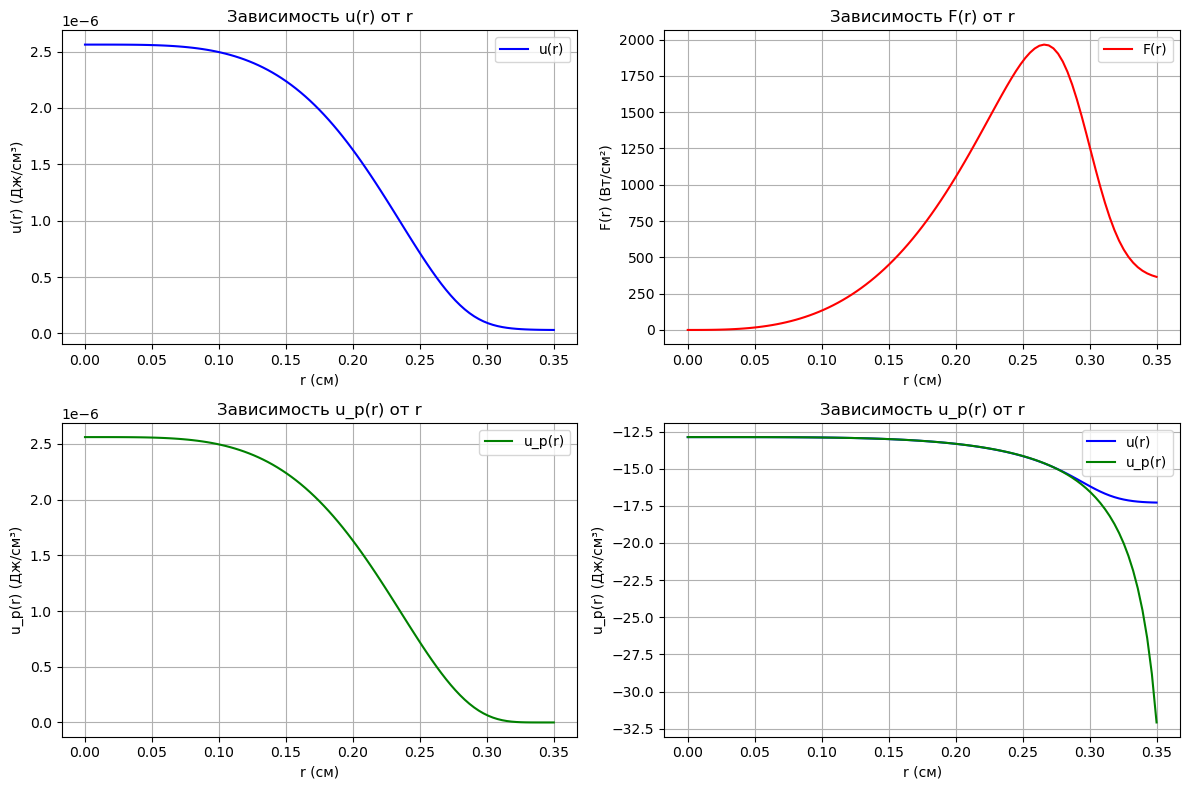

In [1]:
# 1. Алгоритм и программа, реализующие решение сформулированной краевой задачи све-
# дением ее к задаче Коши (метод стрельбы).

import matplotlib.pyplot as plt
from decimal import Decimal, getcontext
import math

getcontext().prec = 50

# Константы
c = Decimal('3e10')       # Скорость света
R = Decimal('0.35')     # Радиус цилиндра
T_w = Decimal('2000')     # Температура на стенке
T_0 = Decimal('10000')    # Температура в центре
p = Decimal('4')        # Параметр температурного профиля

# Данные из таблицы (Вариант 2)
T_values = [Decimal(str(t)) for t in [2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]]
# k_values = [Decimal(str(k)) for k in [8.200E-03, 2.768E-02, 6.560E-02, 1.281E-01, 2.214E-01, 3.516E-01, 5.248E-01, 7.472E-01, 1.025E+00]]
k_values = [Decimal(str(k)) for k in [1.600E+00, 5.400E+00, 1.280E+01, 2.500E+01, 4.320E+01, 6.860E+01, 1.024E+02, 1.458E+02, 2.000E+02]]
# Функция для вычисления T(r)
def T(r):
    return (T_w - T_0) * (r / R)**p + T_0

# Функция для вычисления u_p(r)
def u_p(r):
    return Decimal('3.084e-4') / (Decimal.exp(Decimal('4.799e4') / T(r)) - Decimal('1'))

def linear_interp(x, x0, x1, y0, y1):
    return y0 + (y1 - y0) * (x - x0) / (x1 - x0)

def k_linear(r):
    temp = T(r)
    # если вышли за границы
    if temp < T_values[0]:
        return k_values[0]
    if temp > T_values[-1]:
        return k_values[-1]
    
    for i in range(len(T_values) - 1):
        if (T_values[i] <= temp <= T_values[i + 1]):
            return linear_interp(temp, T_values[i], T_values[i + 1], k_values[i], k_values[i + 1])

def quadratic_interp(x, x0, x1, x2, y0, y1, y2):
    L0 = (x - x1) * (x - x2) / ((x0 - x1) * (x0 - x2))
    L1 = (x - x0) * (x - x2) / ((x1 - x0) * (x1 - x2))
    L2 = (x - x0) * (x - x1) / ((x2 - x0) * (x2 - x1))
    return y0 * L0 + y1 * L1 + y2 * L2

def k_quadratic(r):
    temp = T(r)    
    # если вышли за границы
    if temp < T_values[0]:
        return k_values[0]
    if temp > T_values[-1]:
        return k_values[-1]
    
    # ищем ближайшие 3 точки
    for i in range(1, len(T_values) - 1):
        if (T_values[i - 1] <= temp <= T_values[i + 1]):
            return quadratic_interp(
                temp,
                T_values[i - 1], T_values[i], T_values[i + 1],
                k_values[i - 1], k_values[i], k_values[i + 1]
            )

def dudr(r, F):
    return -(Decimal('3') * k_quadratic(r) / c) * F

def dFdr(r, F, u):
    if (r == Decimal('0')):
        return (c * k_quadratic(r) * (u_p(r) - u)) / Decimal('2')
    else:
        return -F/r + (c * k_quadratic(r) * (u_p(r) - u))

# Метод Рунге-Кутты 2-го порядка
def rk2(r_start, r_end, u_start, F_start, n_steps):
    h = (r_end - r_start) / Decimal(str(n_steps))
    r = r_start
    u = u_start
    F = F_start
    results = [(r, u, F)]
    
    for _ in range(n_steps):
        # промежуточный шаг (1,2 по лекции в точке r + h/2)
        k1_u = dudr(r, F)
        k1_F = dFdr(r, F, u)
        
        u_mid = u + (h/Decimal('2')) * k1_u
        F_mid = F + (h/Decimal('2')) * k1_F
        r_mid = r + (h/Decimal('2'))
        
        # основной шаг (3 по лекции)
        k2_u = dudr(r_mid, F_mid)
        k2_F = dFdr(r_mid, F_mid, u_mid)
        
        u += h * k2_u
        F += h * k2_F
        r += h
        
        results.append((r, u, F))
    
    return results

# Метод Рунге-Кутты 4-го порядка
def rk4(r_start, r_end, u_start, F_start, n_steps=1000):
    h = (r_end - r_start) / Decimal(str(n_steps))
    r = r_start
    u = u_start
    F = F_start
    results = [(r, u, F)]
    
    for _ in range(n_steps):
        # k1
        k1_u = dudr(r, F)
        k1_F = dFdr(r, F, u)
        
        # k2
        u_temp = u + (h/Decimal('2')) * k1_u
        F_temp = F + (h/Decimal('2')) * k1_F
        r_temp = r + (h/Decimal('2'))
        
        k2_u = dudr(r_temp, F_temp)
        k2_F = dFdr(r_temp, F_temp, u_temp)
        
        # k3
        u_temp = u + (h/Decimal('2')) * k2_u
        F_temp = F + (h/Decimal('2')) * k2_F
        r_temp = r + (h/Decimal('2'))
        
        k3_u = dudr(r_temp, F_temp)
        k3_F = dFdr(r_temp, F_temp, u_temp)
        
        # k4
        u_temp = u + h * k3_u
        F_temp = F + h * k3_F
        r_temp = r + h
        
        k4_u = dudr(r_temp, F_temp)
        k4_F = dFdr(r_temp, F_temp, u_temp)
        
        #
        u += h / Decimal('6') * (k1_u + Decimal('2')*k2_u + Decimal('2')*k3_u + k4_u)
        F += h / Decimal('6') * (k1_F + Decimal('2')*k2_F + Decimal('2')*k3_F + k4_F)
        r += h
        
        results.append((r, u, F))
    
    return results


def shooting_method(r_start, r_end, F0, n_steps, rk, chi_low=Decimal('0'), chi_high=Decimal('1'), tol=Decimal('1e-8'), max_iter=1000):
    u_p0 = u_p(r_start)
    
    # ошибка
    def compute_err(chi):
        u0 = chi * u_p0
        solution = rk(r_start, r_end, u0, F0, n_steps)
        r_final, u_final, F_final = solution[-1]
        return (F_final - Decimal('0.39') * u_final * c) / abs(F_final) * 100
    
    # Проверяем начальные границы
    err_low = compute_err(chi_low)
    err_high = compute_err(chi_high)
    # print(err_low, err_high)

    if err_low * err_high > Decimal('0'):
        raise ValueError("Начальные границы chi не охватывают корень")
    
    # Метод бисекции
    for _ in range(max_iter):
        chi_mid = (chi_low + chi_high) / Decimal('2')
        # print(chi_mid)
        err_mid = compute_err(chi_mid)
        
        if (abs(err_mid) < tol):
            return chi_mid
        
        if (err_mid * err_low < Decimal('0')):
            chi_high = chi_mid
            err_high = err_mid
        else:
            chi_low = chi_mid
            err_low = err_mid
    
    raise ValueError(f"Метод бисекции не сощелся за {max_iter}\n")

def print_res(rk_num, chi_opt, u0_opt, u_R, F_R):
    print(f"Метод Рунге-Кутты {rk_num}-го порядка")
    print("Оптимальное chi:", chi_opt)
    print("Начальное u(0):", u0_opt)
    print("Решение u(r):", u_R)
    print("Решение F(r):", F_R)
    print("k_linear(r):", k_linear(R))
    print("k_quadratic(r):", k_quadratic(R))
    print("dudr(r):", dudr(R, F_R))
    print()
    print("k_linear(0.1575):", k_linear(Decimal('0.1575')))
    print("k_quadratic(0.1575):", k_quadratic(Decimal('0.1575')))
    print("dudr(0.1575):", dudr(Decimal('0.1575'), Decimal('1800.9813307543950820')))

def plot_solution(solution):
    r_vals = [float(x[0]) for x in solution]
    u_vals = [float(x[1]) for x in solution]
    F_vals = [float(x[2]) for x in solution]
    u_p_vals = [float(u_p(Decimal(str(r)))) for r in r_vals]
    
    plt.figure(figsize=(12, 8))
    
    # График u(r)
    plt.subplot(2, 2, 1)
    plt.plot(r_vals, u_vals, 'b-', label='u(r)')
    plt.xlabel('r (см)')
    plt.ylabel('u(r) (Дж/см³)')
    plt.title('Зависимость u(r) от r')
    plt.grid(True)
    plt.legend()
    
    # График F(r)
    plt.subplot(2, 2, 2)
    plt.plot(r_vals, F_vals, 'r-', label='F(r)')
    plt.xlabel('r (см)')
    plt.ylabel('F(r) (Вт/см²)')
    plt.title('Зависимость F(r) от r')
    plt.grid(True)
    plt.legend()
    
    # График u_p(r)
    plt.subplot(2, 2, 3)
    plt.plot(r_vals, u_p_vals, 'g-', label='u_p(r)')
    plt.xlabel('r (см)')
    plt.ylabel('u_p(r) (Дж/см³)')
    plt.title('Зависимость u_p(r) от r')
    plt.grid(True)
    plt.legend()

    # График u_p(r)
    plt.subplot(2, 2, 4)
    plt.plot(r_vals, list(map(math.log, u_vals)), 'b-', label='u(r)')
    plt.plot(r_vals, list(map(math.log, u_p_vals)), 'g-', label='u_p(r)')
    plt.xlabel('r (см)')
    plt.ylabel('u_p(r) (Дж/см³)')
    plt.title('Зависимость u_p(r) от r')
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    r_start = Decimal('0')
    r_end = R
    F0 = Decimal('0')
    n_steps = 100
    tol=Decimal('1e-8')
    max_iter=1000

    chi_opt = shooting_method(r_start, r_end, F0, n_steps, rk2, chi_low=Decimal('0.95'), tol=tol, max_iter=max_iter)
    u0_opt = chi_opt * u_p(0)
    solution2 = rk2(r_start, r_end, u0_opt, F0, n_steps)
    u_R = solution2[-1][1]
    F_R = solution2[-1][2]
    print_res(2, chi_opt, u0_opt, u_R, F_R)
    print("r = ", solution2[-1][0], "\n")
    # for i in range(len(solution2)):
    #     print(solution2[i])
    plot_solution(solution2)

    chi_opt = shooting_method(r_start, r_end, F0, n_steps, rk4, tol=tol, max_iter=max_iter)
    u0_opt = chi_opt * u_p(0)
    solution4 = rk4(r_start, r_end, u0_opt, F0, n_steps)
    u_R = solution4[-1][1]
    F_R = solution4[-1][2]
    print_res(4, chi_opt, u0_opt, u_R, F_R)
    print("r = ", solution4[-1][0])

    F_values = [solution[2] for solution in solution4]
    max_F = max(F_values)
    print("Fmax = ", max_F)
    # for i in range(len(solution4)):
    #     print(solution4[i])
    plot_solution(solution4)

[Decimal('0.00'), Decimal('0.00035035035035035035035035035035035035035035035035035'), Decimal('0.00070070070070070070070070070070070070070070070070070'), Decimal('0.0010510510510510510510510510510510510510510510510511'), Decimal('0.0014014014014014014014014014014014014014014014014014'), Decimal('0.0017517517517517517517517517517517517517517517517518'), Decimal('0.0021021021021021021021021021021021021021021021021021'), Decimal('0.0024524524524524524524524524524524524524524524524525'), Decimal('0.0028028028028028028028028028028028028028028028028028'), Decimal('0.0031531531531531531531531531531531531531531531531532'), Decimal('0.0035035035035035035035035035035035035035035035035035'), Decimal('0.0038538538538538538538538538538538538538538538538539'), Decimal('0.0042042042042042042042042042042042042042042042042042'), Decimal('0.0045545545545545545545545545545545545545545545545546'), Decimal('0.0049049049049049049049049049049049049049049049049049'), Decimal('0.0052552552552552552552552552552

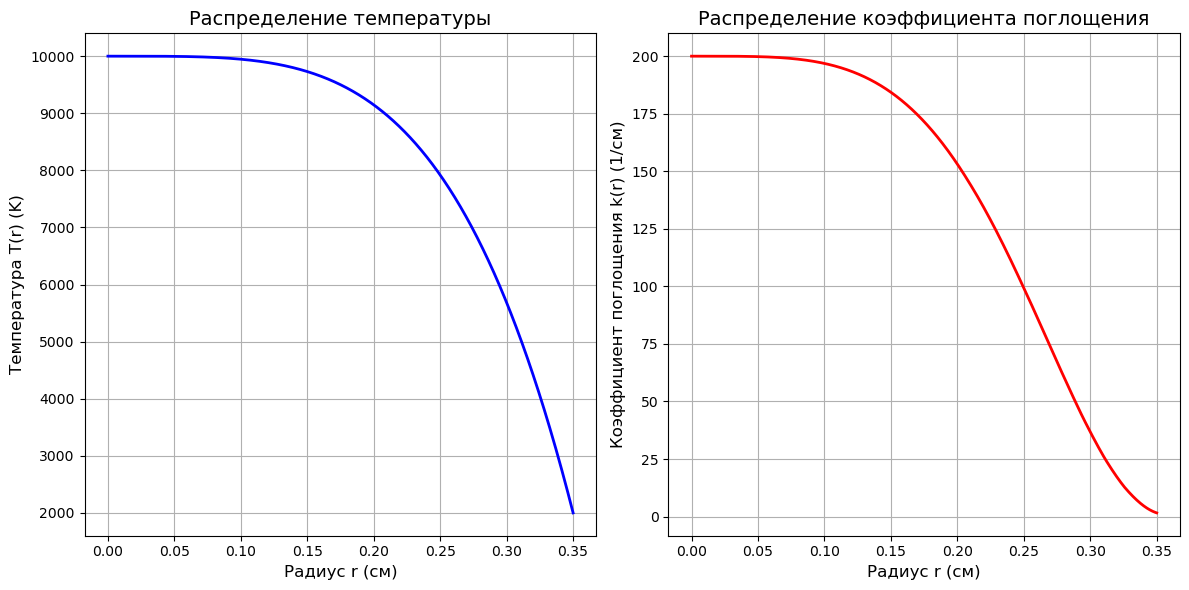

In [2]:
def plot_temperature_and_conductivity(r_start=Decimal('0'), r_end=R, n_steps=1000):
    r_values = [r_start + (r_end - r_start) * Decimal(i) / Decimal(n_steps - 1) 
               for i in range(n_steps)]
    
    print(r_values)
    T_vals = [T(r) for r in r_values]
    k_vals = [k_quadratic(r) for r in r_values]
    
    r_float = [float(r) for r in r_values]
    T_float = [float(t) for t in T_vals]
    k_float = [float(k) for k in k_vals]
    
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(r_float, T_float, 'b-', linewidth=2)
    plt.xlabel('Радиус r (см)', fontsize=12)
    plt.ylabel('Температура T(r) (K)', fontsize=12)
    plt.title('Распределение температуры', fontsize=14)
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(r_float, k_float, 'r-', linewidth=2)
    plt.xlabel('Радиус r (см)', fontsize=12)
    plt.ylabel('Коэффициент поглощения k(r) (1/см)', fontsize=12)
    plt.title('Распределение коэффициента поглощения', fontsize=14)
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # r_start = Decimal('0')
    # r_end = Decimal('0.40')
    plot_temperature_and_conductivity()

In [3]:
def find_chi_range(rk, chi_start=Decimal('0.1'), chi_end=Decimal('1'), n_steps=100):
    chi_values = [chi_start + (chi_end - chi_start) * Decimal(i) / Decimal(n_steps - 1) 
            for i in range(n_steps)]
    valid_chi = []

    r_start = Decimal('0')
    r_end = R
    F0 = Decimal('0')
    n_steps = 100
    tol=Decimal('1e-8')
    max_iter=1000

    for i in range(len(chi_values) - 1):
        try:
            chi_opt = shooting_method(r_start, r_end, F0, n_steps, rk, chi_values[i], chi_values[i + 1], tol, max_iter)
            print(chi_opt)
        except ValueError:
            continue
        else:
            valid_chi.append(chi_values[i])
            valid_chi.append(chi_values[i + 1])

    # print(chi_values)
    # print(valid_chi)
    return min(valid_chi), max(valid_chi)


chi_min_rk2, chi_max_rk2 = find_chi_range(rk2)
print(f"Диапазон chi для RK2: [{chi_min_rk2}, {chi_max_rk2}]")

chi_min_rk4, chi_max_rk4 = find_chi_range(rk4)
print(f"Диапазон chi для RK4: [{chi_min_rk4}, {chi_max_rk4}]")

0.99999855386893470562917187441456110933766587863285
Диапазон chi для RK2: [0.99090909090909090909090909090909090909090909090909, 1.0]
0.9999988469639559144281079192856921667366381408061
Диапазон chi для RK4: [0.99090909090909090909090909090909090909090909090909, 1.0]


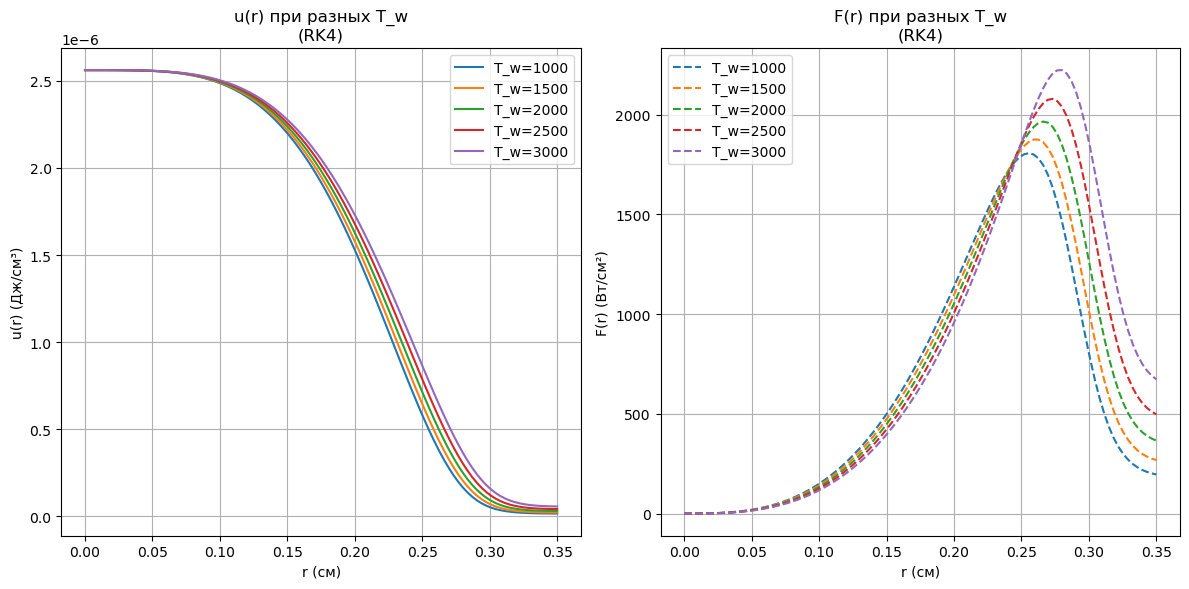

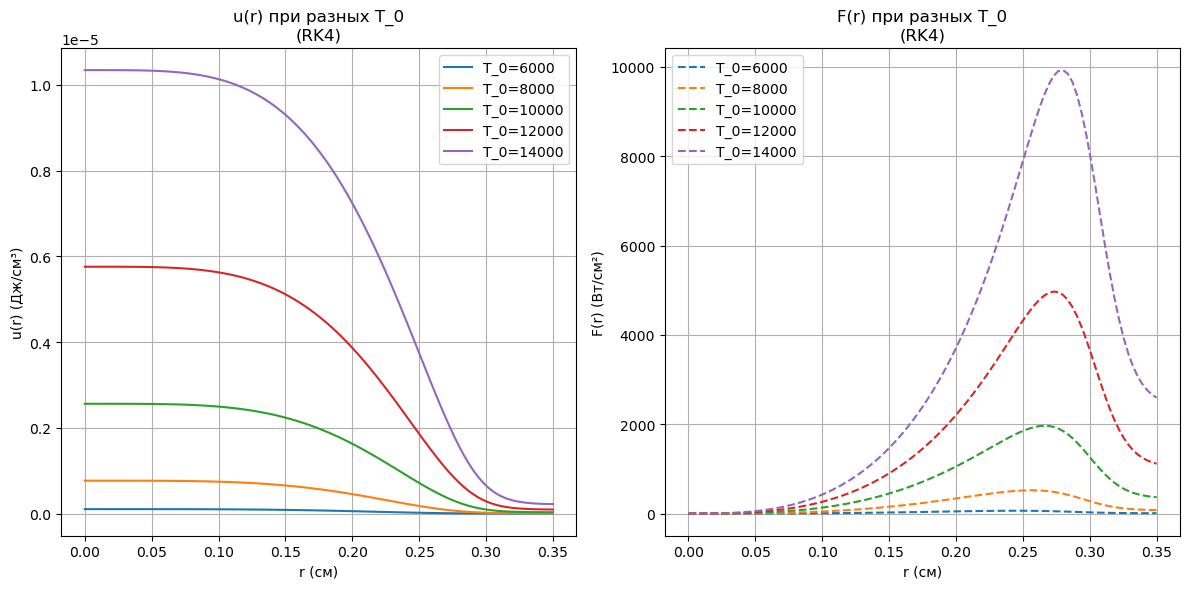

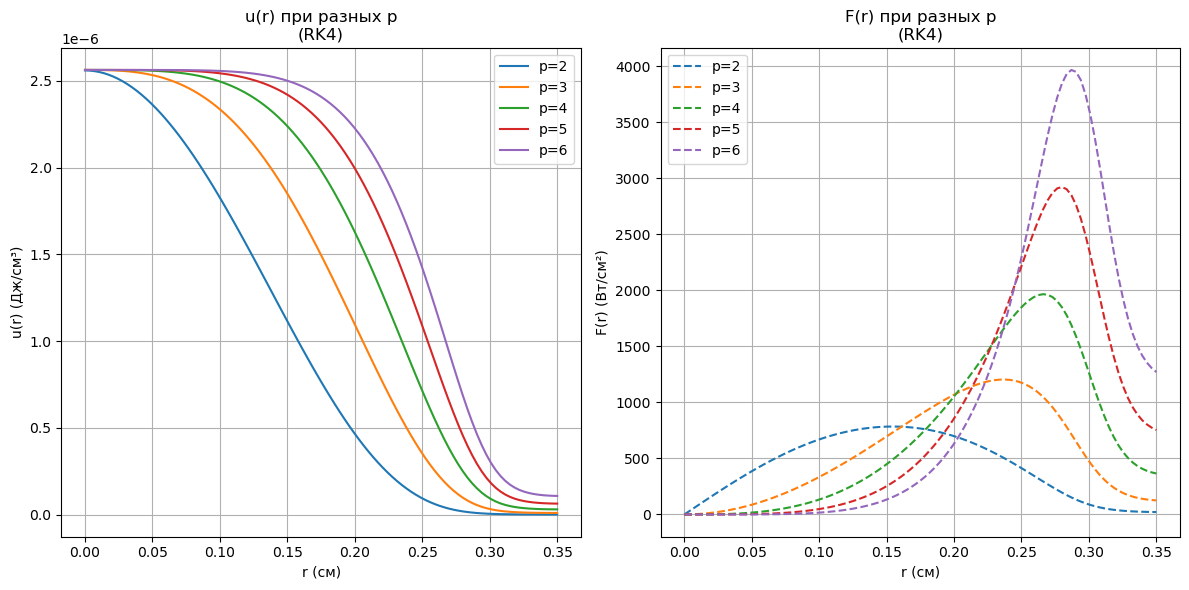

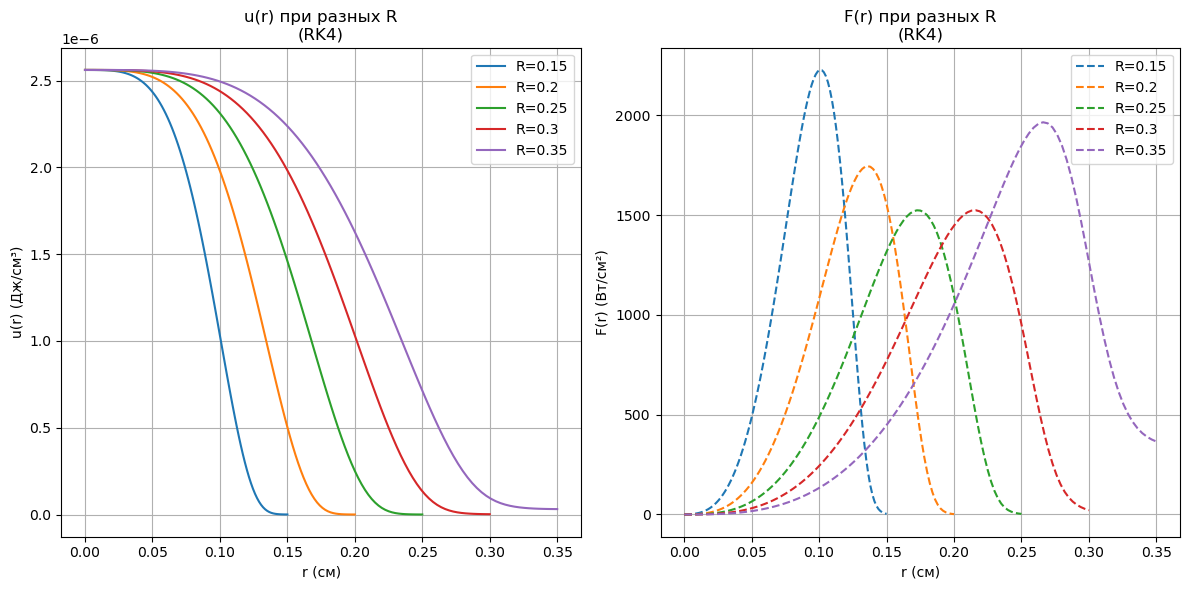

In [4]:
# 3. Результаты исследования влияния параметров задачи на выходные данные, т.е. зависимости
# F(r), u(r) от коэффициента k(T) (изменяя данные в таблице 1), а также от T_w, T_0, p, R

def dFdr_u(r, F, u, u_p):
    if (r == Decimal('0')):
        return (c * k_quadratic(r) * (u_p(r) - u)) / Decimal('2')
    else:
        return -F/r + (c * k_quadratic(r) * (u_p(r) - u))

# Метод Рунге-Кутты 4-го порядка
def rk4_u(r_start, r_end, u_start, F_start, u_p=u_p, n_steps=1000):
    h = (r_end - r_start) / Decimal(str(n_steps))
    r = r_start
    u = u_start
    F = F_start
    results = [(r, u, F)]
    
    for _ in range(n_steps):
        # k1
        k1_u = dudr(r, F)
        k1_F = dFdr_u(r, F, u, u_p=u_p)
        
        # k2
        u_temp = u + (h/Decimal('2')) * k1_u
        F_temp = F + (h/Decimal('2')) * k1_F
        r_temp = r + (h/Decimal('2'))
        
        k2_u = dudr(r_temp, F_temp)
        k2_F = dFdr_u(r_temp, F_temp, u_temp, u_p=u_p)
        
        # k3
        u_temp = u + (h/Decimal('2')) * k2_u
        F_temp = F + (h/Decimal('2')) * k2_F
        r_temp = r + (h/Decimal('2'))
        
        k3_u = dudr(r_temp, F_temp)
        k3_F = dFdr_u(r_temp, F_temp, u_temp, u_p=u_p)
        
        # k4
        u_temp = u + h * k3_u
        F_temp = F + h * k3_F
        r_temp = r + h
        
        k4_u = dudr(r_temp, F_temp)
        k4_F = dFdr_u(r_temp, F_temp, u_temp, u_p=u_p)
        
        #
        u += h / Decimal('6') * (k1_u + Decimal('2')*k2_u + Decimal('2')*k3_u + k4_u)
        F += h / Decimal('6') * (k1_F + Decimal('2')*k2_F + Decimal('2')*k3_F + k4_F)
        r += h
        
        results.append((r, u, F))
    
    return results


def shooting_method_u(r_start, r_end, F0, n_steps, rk, u_p, chi_low=Decimal('0'), chi_high=Decimal('1'), tol=Decimal('1e-8'), max_iter=1000):
    u_p0 = u_p(r_start)
    
    # ошибка
    def compute_err(chi):
        u0 = chi * u_p0
        solution = rk(r_start, r_end, u0, F0, u_p, n_steps)
        r_final, u_final, F_final = solution[-1]
        return (F_final - Decimal('0.39') * u_final * c) / abs(F_final) * 100
    
    # Проверяем начальные границы
    err_low = compute_err(chi_low)
    err_high = compute_err(chi_high)
    # print(err_low, err_high)

    if err_low * err_high > Decimal('0'):
        raise ValueError("Начальные границы chi не охватывают корень")
    
    # Метод бисекции
    for _ in range(max_iter):
        chi_mid = (chi_low + chi_high) / Decimal('2')
        err_mid = compute_err(chi_mid)
        
        if (abs(err_mid) < tol):
            return chi_mid
        
        if (err_mid * err_low < Decimal('0')):
            chi_high = chi_mid
            err_high = err_mid
        else:
            chi_low = chi_mid
            err_low = err_mid
    
    raise ValueError(f"Метод бисекции не сощелся за {max_iter}\n")

def investigate_parameters(u_p_func, R, rk_func, n_steps=1000):
    chi_opt = shooting_method_u(Decimal('0'), R, Decimal('0'), n_steps, rk=rk_func, u_p=u_p_func, chi_low=Decimal('0'), chi_high=Decimal('10'), tol=Decimal('1e-2'))
    u0_opt = chi_opt * u_p_func(Decimal('0'))
    return rk_func(Decimal('0'), R, u0_opt, Decimal('0'), u_p=u_p_func, n_steps=n_steps)

# Исследование влияния T_w
def investigate_T_w(T_w_values, rk, n_steps=1000):
    results = []
    for T_w in T_w_values:
        T_w_dec = Decimal(str(T_w))
        
        def T_new(r):
            return (T_w_dec - T_0) * (r / R)**p + T_0
        def u_p_new(r):
            return Decimal('3.084e-4') / (Decimal.exp(Decimal('4.799e4') / T_new(r)) - Decimal('1'))
        
        solution = investigate_parameters(u_p_new, R, rk, n_steps)
        results.append((solution, T_w))
    return results

# Исследование влияния T_0
def investigate_T_0(T_0_values, rk, n_steps=1000):
    results = []
    for T_0_val in T_0_values:
        T_0_dec = Decimal(str(T_0_val))
        
        def T_new(r):
            return (T_w - T_0_dec) * (r / R)**p + T_0_dec
        def u_p_new(r):
            return Decimal('3.084e-4') / (Decimal.exp(Decimal('4.799e4') / T_new(r)) - Decimal('1'))
        
        solution = investigate_parameters(u_p_new, R, rk, n_steps)
        results.append((solution, T_0_val))
    return results

# Исследование влияния p
def investigate_p(p_values, rk, n_steps=1000):
    results = []
    for p_val in p_values:
        p_dec = Decimal(str(p_val))
        
        def T_new(r):
            return (T_w - T_0) * (r / R)**p_dec + T_0
        def u_p_new(r):
            return Decimal('3.084e-4') / (Decimal.exp(Decimal('4.799e4') / T_new(r)) - Decimal('1'))
        
        solution = investigate_parameters(u_p_new, R, rk, n_steps)
        results.append((solution, p_val))
    return results

# Исследование влияния R
def investigate_R(R_values, rk, n_steps=1000):
    results = []
    for R_val in R_values:
        R_dec = Decimal(str(R_val))
        
        def T_new(r):
            return (T_w - T_0) * (r / R_dec)**p + T_0
        def u_p_new(r):
            return Decimal('3.084e-4') / (Decimal.exp(Decimal('4.799e4') / T_new(r)) - Decimal('1'))

        solution = investigate_parameters(u_p_new, R_dec, rk, n_steps)
        results.append((solution, R_val))
    return results

def plot_investigation_results(results, param_name, rk_name):
    plt.figure(figsize=(12, 6))
    
    # График u(r)
    plt.subplot(1, 2, 1)
    for solution, param_val in results:
        r_vals = [float(x[0]) for x in solution]
        u_vals = [float(x[1]) for x in solution]
        plt.plot(r_vals, u_vals, label=f'{param_name}={param_val}')
    plt.xlabel('r (см)')
    plt.ylabel('u(r) (Дж/см³)')
    plt.title(f'u(r) при разных {param_name}\n({rk_name})')
    plt.legend()
    plt.grid(True)
    
    # График F(r)
    plt.subplot(1, 2, 2)
    for solution, param_val in results:
        r_vals = [float(x[0]) for x in solution]
        F_vals = [float(x[2]) for x in solution]
        plt.plot(r_vals, F_vals, '--', label=f'{param_name}={param_val}')
    plt.xlabel('r (см)')
    plt.ylabel('F(r) (Вт/см²)')
    plt.title(f'F(r) при разных {param_name}\n({rk_name})')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# Исследование влияния T_w
T_w_values = [1000, 1500, 2000, 2500, 3000]
results_T_w = investigate_T_w(T_w_values, rk4_u, n_steps=100)
plot_investigation_results(results_T_w, 'T_w', 'RK4')

# Исследование влияния T_0
T_0_values = [6000, 8000, 10000, 12000, 14000]
results_T_0 = investigate_T_0(T_0_values, rk4_u, n_steps=100)
plot_investigation_results(results_T_0, 'T_0', 'RK4')

# Исследование влияния p
p_values = [2, 3, 4, 5, 6]
results_p = investigate_p(p_values, rk4_u, n_steps=100)
plot_investigation_results(results_p, 'p', 'RK4')

# Исследование влияния R
R_values = [0.15, 0.20, 0.25, 0.30, 0.35]
results_R = investigate_R(R_values, rk4_u, n_steps=100)
plot_investigation_results(results_R, 'R', 'RK4')

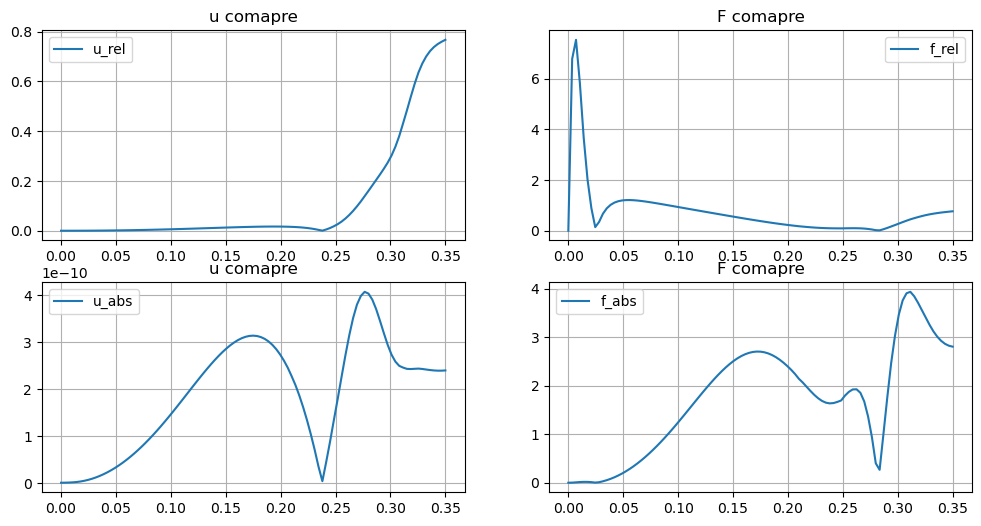

rk2 Real_F (368.42135586488337) - F_R(368.42135587077723) = 5.89386672800174e-09
rk4 Real_F (365.61761533980706) - F_R(365.61761531521023) = 2.4596829462097958e-08


In [5]:
def compare_methods_impl(results_1, results_2, calc_err):
    r_vals_1 = [float(x[0]) for x in results_1]
    u_vals_1 = [float(x[1]) for x in results_1]
    F_vals_1 = [float(x[2]) for x in results_1]

    r_vals_2 = [float(x[0]) for x in results_2]
    u_vals_2 = [float(x[1]) for x in results_2]
    F_vals_2 = [float(x[2]) for x in results_2]

    u_cmp = [calc_err(u1, u2)
             for u1, u2 in zip(u_vals_1, u_vals_2)]

    F_cmp = [calc_err(f1, f2)
             for f1, f2 in zip(F_vals_1, F_vals_2)]

    return r_vals_1, u_cmp, F_cmp

def compare_methods_relative(results_1, results_2):
    return compare_methods_impl(results_1, results_2, 
                lambda a, b: ((abs(a - b)/abs(b) * 100) if b != 0 else 0))

def compare_methods_absolute(results_1, results_2):
    return compare_methods_impl(results_1, results_2,
                                lambda a, b: abs(a - b))

if __name__ == "__main__":
    r_start = Decimal('0')
    r_end = R
    F0 = Decimal('0')
    n_steps = 100
    tol=Decimal('1e-8')
    max_iter=1000

    chi_opt = shooting_method(r_start, r_end, F0, n_steps, rk2, tol=tol, max_iter=max_iter)
    u0_opt = chi_opt * u_p(0)
    solution2 = rk2(r_start, r_end, u0_opt, F0, n_steps)

    chi_opt = shooting_method(r_start, r_end, F0, n_steps, rk4, tol=tol, max_iter=max_iter)
    u0_opt = chi_opt * u_p(0)
    solution4 = rk4(r_start, r_end, u0_opt, F0, n_steps)

    r_vals, u_cmp_rel, F_cmp_rel = compare_methods_relative(solution2, solution4)
    _, u_cmp_abs, F_cmp_abs = compare_methods_absolute(solution2, solution4)
    
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 2, 1)
    plt.plot(r_vals, u_cmp_rel, label="u_rel")
    plt.title('u comapre')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 2)
    plt.plot(r_vals, F_cmp_rel, label="f_rel")
    plt.title('F comapre')
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 3)
    plt.plot(r_vals, u_cmp_abs, label="u_abs")
    plt.title('u comapre')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(2, 2, 4)
    plt.plot(r_vals, F_cmp_abs, label="f_abs")
    plt.title('F comapre')
    plt.legend()
    plt.grid(True)
    
    plt.show()


    def compare_boundary(solution, title):
        U_R = solution[-1][1]
        F_R = float(solution[-1][2])
        real_F_R = float(Decimal('0.39')*c*U_R)
        print(title, f"Real_F ({real_F_R}) - F_R({F_R}) = {abs(real_F_R - F_R)}")

    compare_boundary(solution2, "rk2")
    compare_boundary(solution4, "rk4")